# Full-Mode Ensemble Competency Evaluation

This notebook evaluates real predictive competence of the webapp full-mode model set as an ensemble.

Scope:
- Dataset: `EDA/analysis/s3_snapshots/reports/residual_long_selected_2026-03-06.csv`
- Base learners (full-mode 4): `gbdt+concat`, `concat_mlp+max_pool`, `gated_fusion_mlp+concat`, `ridge+sum_pool`
- Separate evaluation for horizons `7` and `30`
- Deterministic blends + aggressive OOF stacker search
- Range quality metrics via the same robust padded range math used by backend


In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, HuberRegressor, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

BASE_MODELS = [
    ("gbdt", "concat"),
    ("concat_mlp", "max_pool"),
    ("gated_fusion_mlp", "concat"),
    ("ridge", "sum_pool"),
]
BASE_COLS = [f"{m}__{s}" for (m, s) in BASE_MODELS]

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(12):
        if (cur / ".git").exists() and (cur / "virality-webapp").exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError("Could not locate repository root from current working directory")

REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / "EDA" / "analysis" / "s3_snapshots" / "reports" / "residual_long_selected_2026-03-06.csv"
METRICS_PATH = REPO_ROOT / "EDA" / "analysis" / "s3_snapshots" / "reports" / "metrics_selected_2026-03-06.csv"
NOTEBOOK_DIR = REPO_ROOT / "stacking"
if not NOTEBOOK_DIR.exists():
    # Backward compatibility for older layout.
    NOTEBOOK_DIR = REPO_ROOT / "virality-webapp" / "notebooks"
ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"METRICS_PATH: {METRICS_PATH}")
print(f"ARTIFACT_DIR: {ARTIFACT_DIR}")


REPO_ROOT: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor
DATA_PATH: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/EDA/analysis/s3_snapshots/reports/residual_long_selected_2026-03-06.csv
METRICS_PATH: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/EDA/analysis/s3_snapshots/reports/metrics_selected_2026-03-06.csv
ARTIFACT_DIR: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts


In [2]:
ROBUST_RANGE_MIN_SPREAD_LOG = 0.08
ROBUST_RANGE_PAD_SCALE = 0.5
ROBUST_RANGE_PAD_BIAS_LOG = 0.10

def log_to_raw(y_log: np.ndarray | pd.Series | list[float]) -> np.ndarray:
    y = np.asarray(y_log, dtype=float)
    clipped = np.clip(y, -20.0, 30.0)
    return np.clip(np.expm1(clipped), 0.0, None)

def raw_to_log(y_raw: np.ndarray | pd.Series | list[float]) -> np.ndarray:
    y = np.asarray(y_raw, dtype=float)
    return np.log1p(np.clip(y, 0.0, None))

def robust_padded_range_from_logs(log_values: np.ndarray | list[float]) -> dict[str, float]:
    logs = np.sort(np.asarray(log_values, dtype=float).reshape(-1))
    if logs.size == 0:
        raise ValueError("Cannot compute robust range for empty outputs")

    if logs.size >= 4:
        core = logs[1:-1]
    elif logs.size == 3:
        core = logs[1:2]
    else:
        core = logs

    core_low = float(core.min())
    core_high = float(core.max())
    spread = float(max(core_high - core_low, ROBUST_RANGE_MIN_SPREAD_LOG))
    pad = float(ROBUST_RANGE_PAD_SCALE * spread + ROBUST_RANGE_PAD_BIAS_LOG)

    min_log = core_low - pad
    max_log = core_high + pad
    min_raw = float(log_to_raw([min_log])[0])
    max_raw = float(max(min_raw, log_to_raw([max_log])[0]))

    return {
        "min_raw": min_raw,
        "max_raw": max_raw,
        "min_log": float(min_log),
        "max_log": float(max_log),
        "core_min_log": float(core_low),
        "core_max_log": float(core_high),
        "observed_min_log": float(logs.min()),
        "observed_max_log": float(logs.max()),
    }


In [3]:
def regression_metrics(
    y_true_log: np.ndarray,
    y_pred_log: np.ndarray,
    *,
    horizon: int,
    candidate: str,
) -> dict[str, float | int | str]:
    y_true_log = np.asarray(y_true_log, dtype=float).reshape(-1)
    y_pred_log = np.asarray(y_pred_log, dtype=float).reshape(-1)
    if y_true_log.shape[0] != y_pred_log.shape[0]:
        raise ValueError("y_true_log and y_pred_log must have the same length")

    residual_log = y_pred_log - y_true_log
    abs_residual_log = np.abs(residual_log)

    y_true_raw = log_to_raw(y_true_log)
    y_pred_raw = log_to_raw(y_pred_log)
    residual_raw = y_pred_raw - y_true_raw

    denom = np.where(y_true_raw > 0, y_true_raw, np.nan)
    ape = np.abs(residual_raw) / denom
    mape_raw = float(np.nanmean(ape)) if np.isfinite(ape).any() else np.nan

    if y_true_log.size > 1 and np.std(y_true_log) > 0 and np.std(y_pred_log) > 0:
        corr = float(np.corrcoef(y_true_log, y_pred_log)[0, 1])
        r2 = float(r2_score(y_true_log, y_pred_log))
    else:
        corr = np.nan
        r2 = np.nan

    return {
        "horizon": int(horizon),
        "candidate": str(candidate),
        "n": int(y_true_log.size),
        "mae_log": float(np.mean(abs_residual_log)),
        "rmse_log": float(np.sqrt(np.mean(residual_log ** 2))),
        "r2_log": r2,
        "mae_raw": float(np.mean(np.abs(residual_raw))),
        "rmse_raw": float(np.sqrt(np.mean(residual_raw ** 2))),
        "mape_raw": mape_raw,
        "bias_log": float(np.mean(residual_log)),
        "corr_true_pred_log": corr,
        "p95_abs_residual_log": float(np.quantile(abs_residual_log, 0.95)),
    }

def interval_metrics(
    y_true_raw: np.ndarray,
    min_raw: np.ndarray,
    max_raw: np.ndarray,
    *,
    horizon: int,
    candidate: str,
) -> dict[str, float | int | str]:
    y_true_raw = np.asarray(y_true_raw, dtype=float).reshape(-1)
    min_raw = np.asarray(min_raw, dtype=float).reshape(-1)
    max_raw = np.asarray(max_raw, dtype=float).reshape(-1)

    inside = (y_true_raw >= min_raw) & (y_true_raw <= max_raw)
    below = y_true_raw < min_raw
    above = y_true_raw > max_raw
    width = np.maximum(max_raw - min_raw, 0.0)

    return {
        "horizon": int(horizon),
        "candidate": str(candidate),
        "n": int(y_true_raw.size),
        "coverage_raw": float(np.mean(inside)),
        "mean_width_raw": float(np.mean(width)),
        "median_width_raw": float(np.median(width)),
        "p90_width_raw": float(np.quantile(width, 0.90)),
        "under_cover_rate": float(np.mean(below)),
        "over_cover_rate": float(np.mean(above)),
    }


In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not METRICS_PATH.exists():
    raise FileNotFoundError(METRICS_PATH)

residual_df = pd.read_csv(DATA_PATH)
metrics_df = pd.read_csv(METRICS_PATH)

required_residual_cols = {
    "run_id",
    "model_family",
    "strategy",
    "horizon",
    "video_id",
    "text_present",
    "y_true_log",
    "pred_log",
}
missing_residual = sorted(required_residual_cols - set(residual_df.columns))
if missing_residual:
    raise ValueError(f"Residual file missing columns: {missing_residual}")

required_metrics_cols = {"model_family", "strategy", "horizon", "val_mae_log", "test_mae_log"}
missing_metrics = sorted(required_metrics_cols - set(metrics_df.columns))
if missing_metrics:
    raise ValueError(f"Metrics file missing columns: {missing_metrics}")

dup_mask = residual_df.duplicated(
    subset=["video_id", "horizon", "model_family", "strategy"],
    keep=False,
)
if dup_mask.any():
    n_dup = int(dup_mask.sum())
    raise ValueError(f"Found duplicate rows for (video_id,horizon,model_family,strategy): {n_dup}")

full_mask = residual_df[["model_family", "strategy"]].apply(tuple, axis=1).isin(BASE_MODELS)
full_df = residual_df.loc[full_mask].copy()

if full_df.empty:
    raise ValueError("No rows matched full-mode base model set")

print(f"Residual rows (all): {len(residual_df):,}")
print(f"Residual rows (full-mode 4 only): {len(full_df):,}")
print("Unique horizons:", sorted(full_df["horizon"].dropna().unique().tolist()))
print("Rows per model/strategy/horizon:")
print(full_df.groupby(["model_family", "strategy", "horizon"]).size().to_string())


Residual rows (all): 18,492
Residual rows (full-mode 4 only): 6,164
Unique horizons: [7, 30]
Rows per model/strategy/horizon:
model_family      strategy  horizon
concat_mlp        max_pool  7          808
                            30         733
gated_fusion_mlp  concat    7          808
                            30         733
gbdt              concat    7          808
                            30         733
ridge             sum_pool  7          808
                            30         733


In [5]:
def build_horizon_frame(frame: pd.DataFrame, horizon: int) -> pd.DataFrame:
    sub = frame.loc[frame["horizon"] == horizon].copy()
    if sub.empty:
        raise ValueError(f"No rows for horizon={horizon}")

    pivot = sub.pivot_table(
        index="video_id",
        columns=["model_family", "strategy"],
        values="pred_log",
        aggfunc="first",
    )

    missing_pairs = [pair for pair in BASE_MODELS if pair not in pivot.columns]
    if missing_pairs:
        raise ValueError(f"Missing expected base model pairs for horizon={horizon}: {missing_pairs}")

    pivot = pivot.loc[:, BASE_MODELS]
    pivot.columns = BASE_COLS

    y = sub.groupby("video_id")["y_true_log"].first()
    text_present = sub.groupby("video_id")["text_present"].first()

    out = pivot.join(y.rename("y_true_log")).join(text_present.rename("text_present"))
    if out.isna().any().any():
        na_count = int(out.isna().sum().sum())
        raise ValueError(f"Found NA values after pivot/join for horizon={horizon}: {na_count}")

    return out.reset_index()

horizons = sorted(int(h) for h in full_df["horizon"].dropna().unique().tolist())
horizon_frames = {h: build_horizon_frame(full_df, h) for h in horizons}

for h in horizons:
    fr = horizon_frames[h]
    print(f"h={h}: rows={len(fr):,}, cols={fr.shape[1]}")
    print(fr.head(2).to_string(index=False))


h=7: rows=808, cols=7
   video_id  gbdt__concat  concat_mlp__max_pool  gated_fusion_mlp__concat  ridge__sum_pool  y_true_log  text_present
-67kb-NHjHY     11.897232             12.814572                 12.680200        14.929352   14.017763           1.0
-6bye_nqBSE     13.306212             12.674851                 12.982753        11.843652   13.442348           1.0
h=30: rows=733, cols=7
   video_id  gbdt__concat  concat_mlp__max_pool  gated_fusion_mlp__concat  ridge__sum_pool  y_true_log  text_present
-1X5QO57SyQ     13.338489             14.641200                 13.500585        13.773914   15.277415           1.0
-1fDIXoCf7E      6.274668              6.124591                  7.484880         5.895666    6.222576           1.0


In [6]:
def evaluate_base_models(frame: pd.DataFrame, horizon: int) -> pd.DataFrame:
    y = frame["y_true_log"].to_numpy(dtype=float)
    rows = []
    for col, (model_family, strategy) in zip(BASE_COLS, BASE_MODELS):
        m = regression_metrics(y, frame[col].to_numpy(dtype=float), horizon=horizon, candidate=f"base::{model_family}|{strategy}")
        m["family"] = "base"
        m["model_family"] = model_family
        m["strategy"] = strategy
        rows.append(m)
    return pd.DataFrame(rows).sort_values(["rmse_log", "mae_log"], ascending=True).reset_index(drop=True)

def directional_alignment_check(base_df: pd.DataFrame, horizon: int) -> tuple[pd.DataFrame, float]:
    ref_mask = metrics_df["horizon"].astype(int) == int(horizon)
    ref_full = metrics_df.loc[ref_mask].copy()
    ref_full = ref_full[ref_full[["model_family", "strategy"]].apply(tuple, axis=1).isin(BASE_MODELS)]
    ref_full = ref_full[["model_family", "strategy", "test_mae_log"]].copy()

    comp = base_df[["model_family", "strategy", "mae_log", "rmse_log"]].merge(
        ref_full,
        on=["model_family", "strategy"],
        how="left",
    )
    comp["rank_recalc_mae"] = comp["mae_log"].rank(method="min", ascending=True)
    comp["rank_ref_test_mae"] = comp["test_mae_log"].rank(method="min", ascending=True)
    spearman = float(comp[["rank_recalc_mae", "rank_ref_test_mae"]].corr(method="spearman").iloc[0, 1])
    return comp.sort_values("rank_recalc_mae"), spearman

base_results: dict[int, pd.DataFrame] = {}
alignment_results: dict[int, pd.DataFrame] = {}
alignment_spearman: dict[int, float] = {}

for h in horizons:
    base_df_h = evaluate_base_models(horizon_frames[h], h)
    base_results[h] = base_df_h
    align_df_h, spear_h = directional_alignment_check(base_df_h, h)
    alignment_results[h] = align_df_h
    alignment_spearman[h] = spear_h

    print(f"\n=== Base leaderboard (h={h}) ===")
    print(base_df_h[["candidate", "rmse_log", "mae_log", "r2_log", "rmse_raw", "mae_raw"]].to_string(index=False))
    print(f"Directional alignment Spearman rank corr vs metrics_selected test_mae_log (h={h}): {spear_h:.3f}")
    print(alignment_results[h][["model_family", "strategy", "mae_log", "test_mae_log", "rank_recalc_mae", "rank_ref_test_mae"]].to_string(index=False))



=== Base leaderboard (h=7) ===
                    candidate  rmse_log  mae_log   r2_log     rmse_raw       mae_raw
            base::gbdt|concat  1.369527 1.112712 0.412214 2.643980e+06 809351.264855
    base::concat_mlp|max_pool  1.533484 1.224115 0.263053 2.665616e+06 826207.493391
base::gated_fusion_mlp|concat  1.616372 1.302053 0.181233 2.754009e+06 867716.060438
         base::ridge|sum_pool  1.620047 1.302043 0.177506 2.749557e+06 883824.637278
Directional alignment Spearman rank corr vs metrics_selected test_mae_log (h=7): 1.000
    model_family strategy  mae_log  test_mae_log  rank_recalc_mae  rank_ref_test_mae
            gbdt   concat 1.112712      1.112712              1.0                1.0
      concat_mlp max_pool 1.224115      1.224115              2.0                2.0
           ridge sum_pool 1.302043      1.302043              3.0                3.0
gated_fusion_mlp   concat 1.302053      1.302053              4.0                4.0

=== Base leaderboard (h=30) ==

In [7]:
def val_weights_for_horizon(horizon: int) -> pd.Series:
    m = metrics_df.loc[metrics_df["horizon"].astype(int) == int(horizon)].copy()
    m = m[m[["model_family", "strategy"]].apply(tuple, axis=1).isin(BASE_MODELS)]
    m["col"] = m["model_family"].astype(str) + "__" + m["strategy"].astype(str)
    m = m.set_index("col").reindex(BASE_COLS)

    if m["val_mae_log"].isna().any():
        raise ValueError(f"Missing val_mae_log for horizon={horizon} in metrics_selected file")

    inv = 1.0 / m["val_mae_log"].astype(float)
    weights = inv / inv.sum()
    return weights

def deterministic_predictions_and_ranges(frame: pd.DataFrame, horizon: int) -> tuple[dict[str, np.ndarray], pd.DataFrame, pd.Series]:
    X = frame[BASE_COLS].to_numpy(dtype=float)
    preds: dict[str, np.ndarray] = {}

    preds["blend::mean_log"] = X.mean(axis=1)
    preds["blend::median_log"] = np.median(X, axis=1)

    X_sorted = np.sort(X, axis=1)
    if X.shape[1] >= 4:
        preds["blend::trimmed_mean_log"] = X_sorted[:, 1:-1].mean(axis=1)
    else:
        preds["blend::trimmed_mean_log"] = X_sorted.mean(axis=1)

    w = val_weights_for_horizon(horizon)
    preds["blend::val_weighted_mean_log"] = X @ w.to_numpy(dtype=float)

    range_rows = []
    midpoint_log = np.zeros(X.shape[0], dtype=float)
    for i in range(X.shape[0]):
        r = robust_padded_range_from_logs(X[i])
        midpoint_raw = 0.5 * (r["min_raw"] + r["max_raw"])
        midpoint_log[i] = float(raw_to_log([midpoint_raw])[0])
        range_rows.append({
            "video_id": frame.iloc[i]["video_id"],
            "horizon": int(horizon),
            "range_min_raw": float(r["min_raw"]),
            "range_max_raw": float(r["max_raw"]),
            "range_min_log": float(r["min_log"]),
            "range_max_log": float(r["max_log"]),
            "range_width_raw": float(r["max_raw"] - r["min_raw"]),
            "range_midpoint_raw": float(midpoint_raw),
            "range_midpoint_log": float(midpoint_log[i]),
        })

    preds["blend::range_midpoint_log"] = midpoint_log
    range_df = pd.DataFrame(range_rows)
    return preds, range_df, w

deterministic_results: dict[int, pd.DataFrame] = {}
range_rows_by_horizon: dict[int, pd.DataFrame] = {}
val_weights_rows = []

for h in horizons:
    fr = horizon_frames[h]
    y = fr["y_true_log"].to_numpy(dtype=float)
    preds_h, range_df_h, w_h = deterministic_predictions_and_ranges(fr, h)
    rows_h = []
    for name, pred_vec in preds_h.items():
        m = regression_metrics(y, pred_vec, horizon=h, candidate=name)
        m["family"] = "deterministic"
        rows_h.append(m)
    deterministic_results[h] = pd.DataFrame(rows_h).sort_values(["rmse_log", "mae_log"], ascending=True).reset_index(drop=True)
    range_rows_by_horizon[h] = range_df_h

    for col_name, wv in w_h.items():
        val_weights_rows.append({
            "horizon": int(h),
            "base_col": col_name,
            "weight": float(wv),
        })

    print(f"\n=== Deterministic leaderboard (h={h}) ===")
    print(deterministic_results[h][["candidate", "rmse_log", "mae_log", "r2_log", "rmse_raw", "mae_raw"]].to_string(index=False))
    print("Val-weighted blend weights:")
    print(w_h.to_string())

val_weights_df = pd.DataFrame(val_weights_rows).sort_values(["horizon", "base_col"]).reset_index(drop=True)



=== Deterministic leaderboard (h=7) ===
                   candidate  rmse_log  mae_log   r2_log     rmse_raw       mae_raw
blend::val_weighted_mean_log  1.442614 1.167741 0.347804 2.698028e+06 819503.389195
             blend::mean_log  1.452420 1.175099 0.338907 2.701242e+06 821933.354918
           blend::median_log  1.476298 1.191471 0.316992 2.701416e+06 828141.001310
     blend::trimmed_mean_log  1.476298 1.191471 0.316992 2.701416e+06 828141.001310
   blend::range_midpoint_log  1.483008 1.199596 0.310769 2.678939e+06 829503.407565
Val-weighted blend weights:
col
gbdt__concat                0.281916
concat_mlp__max_pool        0.255945
gated_fusion_mlp__concat    0.232022
ridge__sum_pool             0.230117

=== Deterministic leaderboard (h=30) ===
                   candidate  rmse_log  mae_log   r2_log     rmse_raw      mae_raw
blend::val_weighted_mean_log  2.012411 1.552536 0.564492 9.962659e+07 5.610867e+06
             blend::mean_log  2.162148 1.663369 0.497271 4.157439e+

In [8]:
def candidate_estimators(seed: int = SEED) -> dict[str, object]:
    return {
        "stack::linear": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "stack::ridgecv": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 25))),
        ]),
        "stack::lassocv": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(alphas=np.logspace(-4, 1, 40), cv=5, max_iter=20000, random_state=seed)),
        ]),
        "stack::elasticnetcv": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
                alphas=np.logspace(-4, 1, 35),
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                cv=5,
                max_iter=25000,
                random_state=seed,
            )),
        ]),
        "stack::huber": Pipeline([
            ("scaler", StandardScaler()),
            ("model", HuberRegressor(alpha=1e-4, max_iter=300)),
        ]),
        "stack::random_forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=seed,
            n_jobs=-1,
        ),
        "stack::hist_gbdt": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=500,
            random_state=seed,
        ),
    }

def repeated_kfold_oof_predictions(
    X: np.ndarray,
    y: np.ndarray,
    estimator: object,
    *,
    n_splits: int = 5,
    n_repeats: int = 3,
    seed: int = SEED,
) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y row counts do not match")

    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    pred_sum = np.zeros(y.shape[0], dtype=float)
    pred_count = np.zeros(y.shape[0], dtype=int)

    for fold_idx, (train_idx, test_idx) in enumerate(rkf.split(X, y), start=1):
        est = clone(estimator)
        est.fit(X[train_idx], y[train_idx])
        pred_fold = est.predict(X[test_idx])
        pred_sum[test_idx] += pred_fold
        pred_count[test_idx] += 1

    if np.any(pred_count == 0):
        n_zero = int((pred_count == 0).sum())
        raise RuntimeError(f"Some rows were never predicted in OOF loop: {n_zero}")

    return pred_sum / pred_count

stack_results: dict[int, pd.DataFrame] = {}
stack_oof_by_horizon: dict[int, pd.DataFrame] = {}

for h in horizons:
    fr = horizon_frames[h]
    X = fr[BASE_COLS].to_numpy(dtype=float)
    y = fr["y_true_log"].to_numpy(dtype=float)

    ests = candidate_estimators(SEED)
    rows_h = []
    pred_map = {"video_id": fr["video_id"].astype(str).to_numpy(), "y_true_log": y}

    for name, est in ests.items():
        try:
            oof_pred = repeated_kfold_oof_predictions(
                X,
                y,
                est,
                n_splits=5,
                n_repeats=3,
                seed=SEED,
            )
            pred_map[name] = oof_pred
            m = regression_metrics(y, oof_pred, horizon=h, candidate=name)
            m["family"] = "stack"
            m["fit_status"] = "ok"
        except Exception as exc:
            m = {
                "horizon": int(h),
                "candidate": name,
                "family": "stack",
                "fit_status": f"failed: {exc}",
                "n": int(len(y)),
                "mae_log": np.nan,
                "rmse_log": np.nan,
                "r2_log": np.nan,
                "mae_raw": np.nan,
                "rmse_raw": np.nan,
                "mape_raw": np.nan,
                "bias_log": np.nan,
                "corr_true_pred_log": np.nan,
                "p95_abs_residual_log": np.nan,
            }
        rows_h.append(m)

    stack_df_h = pd.DataFrame(rows_h)
    stack_results[h] = stack_df_h.sort_values(["fit_status", "rmse_log"], ascending=[True, True], na_position="last").reset_index(drop=True)
    stack_oof_by_horizon[h] = pd.DataFrame(pred_map)

    print(f"\n=== Stack leaderboard (OOF, h={h}) ===")
    print(stack_results[h][["candidate", "fit_status", "rmse_log", "mae_log", "r2_log", "rmse_raw", "mae_raw"]].to_string(index=False))



=== Stack leaderboard (OOF, h=7) ===
           candidate fit_status  rmse_log  mae_log   r2_log     rmse_raw       mae_raw
       stack::linear         ok  1.358427 1.094458 0.421704 2.601200e+06 808679.147233
      stack::lassocv         ok  1.358439 1.095446 0.421693 2.602573e+06 808506.354940
      stack::ridgecv         ok  1.358549 1.095420 0.421600 2.604540e+06 808239.426603
 stack::elasticnetcv         ok  1.358799 1.095978 0.421387 2.604371e+06 808185.556201
        stack::huber         ok  1.360398 1.091144 0.420025 2.575846e+06 810841.853212
stack::random_forest         ok  1.442309 1.157167 0.348080 2.671117e+06 836191.508050
    stack::hist_gbdt         ok  1.507823 1.201717 0.287511 2.685998e+06 866291.435199

=== Stack leaderboard (OOF, h=30) ===
           candidate fit_status  rmse_log  mae_log   r2_log     rmse_raw      mae_raw
 stack::elasticnetcv         ok  1.600541 1.223052 0.724516 6.473762e+06 1.865758e+06
      stack::lassocv         ok  1.600686 1.221852 0.72

In [9]:
range_metrics_rows = []

for h in horizons:
    fr = horizon_frames[h]
    rr = range_rows_by_horizon[h]

    if not rr["video_id"].astype(str).equals(fr["video_id"].astype(str)):
        rr = rr.set_index("video_id").loc[fr["video_id"].astype(str)].reset_index()

    y_true_raw = log_to_raw(fr["y_true_log"].to_numpy(dtype=float))
    m = interval_metrics(
        y_true_raw,
        rr["range_min_raw"].to_numpy(dtype=float),
        rr["range_max_raw"].to_numpy(dtype=float),
        horizon=h,
        candidate="range::robust_padded",
    )
    range_metrics_rows.append(m)

range_metrics_df = pd.DataFrame(range_metrics_rows).sort_values("horizon").reset_index(drop=True)
print(range_metrics_df.to_string(index=False))


 horizon            candidate   n  coverage_raw  mean_width_raw  median_width_raw  p90_width_raw  under_cover_rate  over_cover_rate
       7 range::robust_padded 808      0.212871    3.206482e+05     140022.408508   7.251129e+05          0.388614         0.398515
      30 range::robust_padded 733      0.287858    5.940490e+09     465682.590023   2.596805e+06          0.321965         0.390177


In [10]:
all_leaderboards: dict[int, pd.DataFrame] = {}
best_summary_rows = []

for h in horizons:
    base_df = base_results[h].copy()
    det_df = deterministic_results[h].copy()
    stack_df = stack_results[h].copy()
    stack_ok = stack_df.loc[stack_df["fit_status"] == "ok"].copy() if "fit_status" in stack_df.columns else stack_df.copy()

    all_df = pd.concat([base_df, det_df, stack_ok], ignore_index=True, sort=False)
    all_df = all_df.sort_values(["rmse_log", "mae_log"], ascending=True).reset_index(drop=True)
    all_leaderboards[h] = all_df

    best_base = base_df.nsmallest(1, "rmse_log").iloc[0]
    best_det = det_df.nsmallest(1, "rmse_log").iloc[0]
    if len(stack_ok) > 0:
        best_stack = stack_ok.nsmallest(1, "rmse_log").iloc[0]
    else:
        best_stack = None

    best_summary_rows.append({
        "horizon": int(h),
        "best_base": best_base["candidate"],
        "best_base_rmse_log": float(best_base["rmse_log"]),
        "best_base_mae_log": float(best_base["mae_log"]),
        "best_det": best_det["candidate"],
        "best_det_rmse_log": float(best_det["rmse_log"]),
        "best_det_mae_log": float(best_det["mae_log"]),
        "best_stack": None if best_stack is None else best_stack["candidate"],
        "best_stack_rmse_log": np.nan if best_stack is None else float(best_stack["rmse_log"]),
        "best_stack_mae_log": np.nan if best_stack is None else float(best_stack["mae_log"]),
    })

    print(f"\n=== Combined leaderboard top-10 (h={h}) ===")
    print(all_df[["candidate", "family", "rmse_log", "mae_log", "r2_log", "rmse_raw", "mae_raw"]].head(10).to_string(index=False))

best_comparison_df = pd.DataFrame(best_summary_rows).sort_values("horizon").reset_index(drop=True)
print("\n=== Best-of summary ===")
print(best_comparison_df.to_string(index=False))



=== Combined leaderboard top-10 (h=7) ===
                   candidate        family  rmse_log  mae_log   r2_log     rmse_raw       mae_raw
               stack::linear         stack  1.358427 1.094458 0.421704 2.601200e+06 808679.147233
              stack::lassocv         stack  1.358439 1.095446 0.421693 2.602573e+06 808506.354940
              stack::ridgecv         stack  1.358549 1.095420 0.421600 2.604540e+06 808239.426603
         stack::elasticnetcv         stack  1.358799 1.095978 0.421387 2.604371e+06 808185.556201
                stack::huber         stack  1.360398 1.091144 0.420025 2.575846e+06 810841.853212
           base::gbdt|concat          base  1.369527 1.112712 0.412214 2.643980e+06 809351.264855
        stack::random_forest         stack  1.442309 1.157167 0.348080 2.671117e+06 836191.508050
blend::val_weighted_mean_log deterministic  1.442614 1.167741 0.347804 2.698028e+06 819503.389195
             blend::mean_log deterministic  1.452420 1.175099 0.338907 2.70

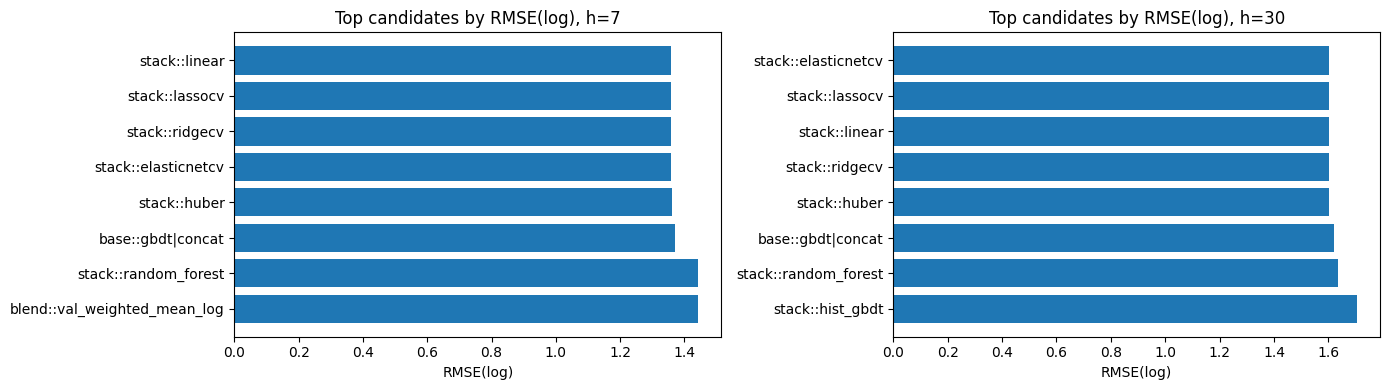

In [11]:
fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 4), sharey=False)
if len(horizons) == 1:
    axes = [axes]

for ax, h in zip(axes, horizons):
    top = all_leaderboards[h].head(8).copy()
    ax.barh(top["candidate"], top["rmse_log"])
    ax.invert_yaxis()
    ax.set_title(f"Top candidates by RMSE(log), h={h}")
    ax.set_xlabel("RMSE(log)")

plt.tight_layout()
plt.show()


In [12]:
exported = []

def export_csv(df: pd.DataFrame, name: str) -> None:
    path = ARTIFACT_DIR / name
    df.to_csv(path, index=False)
    exported.append(path)

export_csv(val_weights_df, "val_weights_by_horizon.csv")
export_csv(range_metrics_df, "range_metrics_summary.csv")
export_csv(best_comparison_df, "best_comparison_summary.csv")

for h in horizons:
    export_csv(base_results[h], f"h{h}_base_leaderboard.csv")
    export_csv(deterministic_results[h], f"h{h}_deterministic_leaderboard.csv")
    export_csv(stack_results[h], f"h{h}_stack_leaderboard.csv")
    export_csv(all_leaderboards[h], f"h{h}_all_leaderboard.csv")
    export_csv(range_rows_by_horizon[h], f"h{h}_range_rows.csv")
    export_csv(stack_oof_by_horizon[h], f"h{h}_stack_oof_predictions.csv")

manifest = pd.DataFrame({
    "generated_at": [datetime.utcnow().isoformat() + "Z"] * len(exported),
    "path": [str(p) for p in exported],
})
export_csv(manifest, "artifact_manifest.csv")

print("Exported artifact files:")
for p in exported:
    print(f"- {p}")


Exported artifact files:
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/val_weights_by_horizon.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/range_metrics_summary.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/best_comparison_summary.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/h7_base_leaderboard.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/h7_deterministic_leaderboard.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/h7_stack_leaderboard.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/h7_all_leaderboard.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifacts/h7_range_rows.csv
- /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/stacking/artifac

/var/folders/dw/kgzc63q13yx4h7yfxw9hn9j80000gn/T/ipykernel_96037/2877853669.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": [datetime.utcnow().isoformat() + "Z"] * len(exported),
